In [25]:
import numpy as np
import matplotlib.pyplot as plt

def grad_Pij(x, e_L, e_R, e_corr):
    """
    Gradients of P00, P01, P10, P11 with respect to
    (e_L, e_R, e_corr).

    Returns
    -------
    grads : dict
        grads["P00"], etc. are arrays:
        [dP/de_L, dP/de_R, dP/de_corr]
    """

    # Decay parameters
    atr = 1 - 2*e_L - 2*e_R
    adt = 1 - 2*e_L - 2*e_R - 6*e_corr
    aL  = 1 - 2*e_L - 2*e_corr
    aR  = 1 - 2*e_R - 2*e_corr

    # Derivatives of S1 = aL^x
    dS1 = np.array([
        -2*x*aL**(x-1),   # e_L
        0,                 # e_R
        -2*x*aL**(x-1)    # e_corr
    ])

    # Derivatives of S2 = aR^x
    dS2 = np.array([
        0,
        -2*x*aR**(x-1),
        -2*x*aR**(x-1)
    ])

    # Derivatives of M1 = (2/3) adt^x
    dM1 = np.array([
        -(4*x/3)*adt**(x-1),
        -(4*x/3)*adt**(x-1),
        -4*x*adt**(x-1)
    ])

    # Derivatives of M2 = (1/3) atr^x
    dM2 = np.array([
        -(2*x/3)*atr**(x-1),
        -(2*x/3)*atr**(x-1),
        0
    ])

    # P00 = (1 + S1 + S2 + M1 + M2)/4
    grad_P00 = ( dS1 + dS2 + dM1 + dM2) / 4

    # P01 = (1 + S1 - S2 - M1 - M2)/4
    grad_P01 = ( dS1 - dS2 - dM1 - dM2) / 4

    # P10 = (1 - S1 + S2 - M1 - M2)/4
    grad_P10 = (-dS1 + dS2 - dM1 - dM2) / 4

    # P11 = (1 - S1 - S2 + M1 + M2)/4
    grad_P11 = (-dS1 - dS2 + dM1 + dM2) / 4

    return {
        "P00": grad_P00,
        "P01": grad_P01,
        "P10": grad_P10,
        "P11": grad_P11,
    }


def fisher_at_x(x, e_L, e_R, e_corr):
    # Compute probabilities here
    atr = 1 - 2*e_L - 2*e_R
    adt = 1 - 2*e_L - 2*e_R - 6*e_corr
    aL  = 1 - 2*e_L - 2*e_corr
    aR  = 1 - 2*e_R - 2*e_corr

    S1 = aL**x
    S2 = aR**x
    M1 = 2*adt**x / 3
    M2 = atr**x / 3

    probs = {
        "P00": (1 + S1 + S2 + M1 + M2) / 4,
        "P01": (1 + S1 - S2 - M1 - M2) / 4,
        "P10": (1 - S1 + S2 - M1 - M2) / 4,
        "P11": (1 - S1 - S2 + M1 + M2) / 4,
    }

    grads = grad_Pij(x, e_L, e_R, e_corr)

    I = np.zeros((3, 3))

    for key in probs:
        g = grads[key]
        I += np.outer(g, g) / probs[key]

    return I

def fisher_for_array(x_array, e_L, e_R, e_corr, N):
    I_total = np.zeros((3, 3))
    for x in x_array:
        I_total += fisher_at_x(x, e_L, e_R, e_corr)
    return N*I_total

def cramer_rao_bound(x_array, e_L, e_R, e_corr, N):
    I_total = fisher_for_array(x_array, e_L, e_R, e_corr, N)
    return np.linalg.inv(I_total)


x_array = np.array([1, 2,4,8,16,32,64,128,256,512,1024])
N = 50*50
e_L = 0.001
e_R = 0.001
e_corr = 0.01
k = 1/e_L

I = fisher_for_array(x_array, e_L, e_R, e_corr, N)
print(f"Fisher information matrix at x={x_array}:\n{I}")

lamda_min = np.min(np.linalg.eigvals(I))/N
vec_min = np.linalg.eig(I)[1][:, np.argmin(np.linalg.eigvals(I))]
vec_min = vec_min / np.linalg.norm(vec_min)  # Normalize the eigenvector
print(f"Minimum eigenvalue of Fisher information matrix: {lamda_min}")
print(f"Eigenvector corresponding to minimum eigenvalue: {vec_min}")

det_I = np.linalg.det(I)/N**3
print(f"Determinant of Fisher information matrix: {det_I}")

cov = cramer_rao_bound(x_array, e_L, e_R, e_corr, N)
print(f"Cramer-Rao bound covariance matrix at x={x_array}:\n{cov}")

std_errors = np.sqrt(np.diag(cov))
print(f"Standard errors for e_L, e_R, e_corr: {std_errors}")

Fisher information matrix at x=[   1    2    4    8   16   32   64  128  256  512 1024]:
[[37496790.45057772 23184258.70077194  9870130.53885007]
 [23184258.70077194 37496790.45057772  9870130.53885007]
 [ 9870130.53885007  9870130.53885007 22043950.2689009 ]]
Minimum eigenvalue of Fisher information matrix: 5725.012699922312
Eigenvector corresponding to minimum eigenvalue: [ 7.07106781e-01 -7.07106781e-01 -1.01172399e-15]
Determinant of Fisher information matrix: 1046817267838.975
Cramer-Rao bound covariance matrix at x=[   1    2    4    8   16   32   64  128  256  512 1024]:
[[ 4.45790373e-08 -2.52898033e-08 -8.63671235e-09]
 [-2.52898033e-08  4.45790373e-08 -8.63671235e-09]
 [-8.63671235e-09 -8.63671235e-09  5.30980583e-08]]
Standard errors for e_L, e_R, e_corr: [0.00021114 0.00021114 0.00023043]


r_arr: [1.00000000e-02 1.09749877e-02 1.20450354e-02 1.32194115e-02
 1.45082878e-02 1.59228279e-02 1.74752840e-02 1.91791026e-02
 2.10490414e-02 2.31012970e-02 2.53536449e-02 2.78255940e-02
 3.05385551e-02 3.35160265e-02 3.67837977e-02 4.03701726e-02
 4.43062146e-02 4.86260158e-02 5.33669923e-02 5.85702082e-02
 6.42807312e-02 7.05480231e-02 7.74263683e-02 8.49753436e-02
 9.32603347e-02 1.02353102e-01 1.12332403e-01 1.23284674e-01
 1.35304777e-01 1.48496826e-01 1.62975083e-01 1.78864953e-01
 1.96304065e-01 2.15443469e-01 2.36448941e-01 2.59502421e-01
 2.84803587e-01 3.12571585e-01 3.43046929e-01 3.76493581e-01
 4.13201240e-01 4.53487851e-01 4.97702356e-01 5.46227722e-01
 5.99484250e-01 6.57933225e-01 7.22080902e-01 7.92482898e-01
 8.69749003e-01 9.54548457e-01 1.04761575e+00 1.14975700e+00
 1.26185688e+00 1.38488637e+00 1.51991108e+00 1.66810054e+00
 1.83073828e+00 2.00923300e+00 2.20513074e+00 2.42012826e+00
 2.65608778e+00 2.91505306e+00 3.19926714e+00 3.51119173e+00
 3.85352859e+00 4

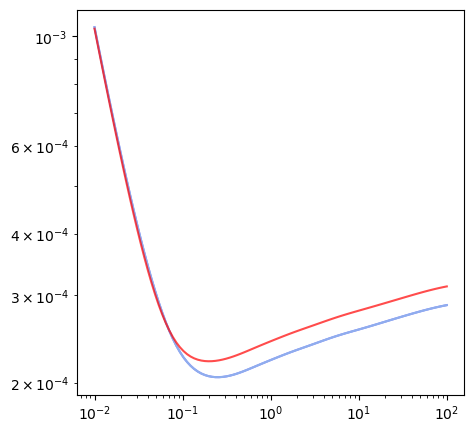

In [57]:

N = 50*50
e_L = 0.001
e_R = 0.001
e_corr = 0.01
k = 1/e_L
r_arr = np.logspace(-2, 2, 100, base=10)  
stderr_e_L = []
stderr_e_R = []
stderr_e_corr = []
for r in r_arr:
    x_max = r*k
    x_array = np.logspace(0, np.log(x_max), 10, base=np.e)  
    I = fisher_for_array(x_array, e_L, e_R, e_corr, N)
    lamda_min = np.min(np.linalg.eigvals(I))/N

    cov = cramer_rao_bound(x_array, e_L, e_R, e_corr, N)

    std_errors = np.sqrt(np.diag(cov))

    stderr_e_L.append(std_errors[0])
    stderr_e_R.append(std_errors[1])
    stderr_e_corr.append(std_errors[2])

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
print(f"r_arr: {r_arr}")
print(f"stderr_e_L: {stderr_e_L}")
ax.plot(r_arr, stderr_e_L, label='e_L', color='blue', alpha=0.7)
ax.plot(r_arr, stderr_e_R, label='e_R', color='lightblue', alpha=0.7)
ax.plot(r_arr, stderr_e_corr, label='e_corr', color='red', alpha=0.7)

ax.set_yscale('log')
ax.set_xscale('log')

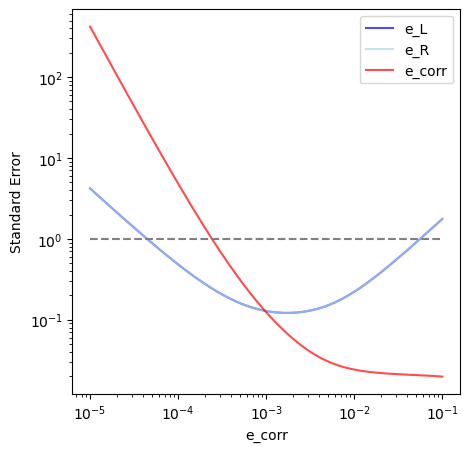

In [81]:

N = 50*50
e_L = 0.001
e_R = 0.001
e_corr_arr = np.logspace(-5, -1, 100, base=10)
k = 1/e_L
x_array = np.logspace(0, np.log(k), 10, base=np.e)
stderr_e_L = np.array([])
stderr_e_R = np.array([])
stderr_e_corr = np.array([])
cov_corr_L = np.array([])
for j, e_corr in enumerate(e_corr_arr):
    I = fisher_for_array(x_array, e_L, e_R, e_corr, N)
    lamda_min = np.min(np.linalg.eigvals(I))/N

    cov = cramer_rao_bound(x_array, e_L, e_R, e_corr, N)
    cov_corr_L = np.append(cov_corr_L, cov[0, 2])

    std_errors = np.sqrt(np.diag(cov))
    stderr_e_L = np.append(stderr_e_L, std_errors[0])
    stderr_e_R = np.append(stderr_e_R, std_errors[1])
    stderr_e_corr = np.append(stderr_e_corr, std_errors[2])


fig, ax = plt.subplots(1, 1, figsize=(5, 5))
# plot
ax.plot(e_corr_arr, stderr_e_L/e_L, label='e_L', color='blue', alpha=0.7)
ax.plot(e_corr_arr, stderr_e_R/e_R, label='e_R', color='lightblue', alpha=0.7)
ax.plot(e_corr_arr, stderr_e_corr/e_corr_arr, label='e_corr', color='red', alpha=0.7)
ax.hlines(y=1, xmin=e_corr_arr[0], xmax=e_corr_arr[-1], colors='gray', linestyles='dashed')
# ax.plot(e_corr_arr, cov_corr_L, label='Cov(e_L, e_corr)', color='green', alpha=0.7)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('e_corr')
ax.set_ylabel('Standard Error')
ax.legend()
